In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
sns.set_theme()
gc.enable()

In [3]:
main_data=pd.read_csv('initial_clean.csv')
main_data.head()

,AMT_ANNUITY,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,DAYS_REGISTRATION,DAYS_LAST_PHONE_CHANGE,EXT_SOURCE_1,...,ORGANIZATION_TYPE,WALLSMATERIAL_MODE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_6,FLAG_EMP_PHONE,FLAG_PHONE,FLAG_WORK_PHONE,LIVE_CITY_NOT_WORK_CITY,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY
0,24700.5,406597.5,202500.0,351000.0,-9461,-637.0,-2120,-3648.0,-1134.0,0.083037,...,Business Entity Type 3,"Stone, brick",1,0,1,1,0,0,0,0
1,35698.5,1293502.5,270000.0,1129500.0,-16765,-1188.0,-291,-1186.0,-828.0,0.311267,...,School,Block,1,0,1,1,0,0,0,0
2,6750.0,135000.0,67500.0,135000.0,-19046,-225.0,-2531,-4260.0,-815.0,NaN,...,Government,NaN,0,0,1,1,1,0,0,0
3,29686.5,312682.5,135000.0,297000.0,-19005,-3039.0,-2437,-9833.0,-617.0,NaN,...,Business Entity Type 3,NaN,1,0,1,0,0,0,0,0
4,21865.5,513000.0,121500.0,513000.0,-19932,-3038.0,-3458,-4311.0,-1106.0,NaN,...,Religion,NaN,0,0,1,0,0,1,0,1


In [4]:
main_data.shape

(307511, 48)

In [5]:
main_data.columns

Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
       'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'TARGET', 'SK_ID_CURR', 'AMT_CREDIT_outlier',
       'AMT_INCOME_TOTAL_outlier', 'AMT_ANNUITY_outlier',
       'AMT_GOODS_PRICE_outlier', 'YEARS_BIRTH', 'YEARS_ID_PUBLISH',
       'YEARS_REGISTRATION', 'DAYS_REGISTRATION_outlier', 'YEARS_EMPLOYED',
       'DAYS_EMPLOYED_outlier', 'YEARS_LAST_PHONE_CHANGE', 'CODE_GENDER',
       'EMERGENCYSTATE_MODE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'NAME_CONTRACT_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE',
       'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_6', 'FLAG_EMP_PHONE', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
       'LIVE_CITY_

In [6]:
numerical_features=pd.Index(['TARGET', 'SK_ID_CURR', 'AMT_ANNUITY', 'AMT_CREDIT', 
                             'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 
                             'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
                             'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                             'EXT_SOURCE_3', 'AMT_CREDIT_outlier', 'AMT_INCOME_TOTAL_outlier', 
                             'AMT_ANNUITY_outlier', 'AMT_GOODS_PRICE_outlier', 'YEARS_BIRTH', 
                             'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION', 'DAYS_REGISTRATION_outlier', 
                             'YEARS_EMPLOYED','DAYS_EMPLOYED_outlier', 'YEARS_LAST_PHONE_CHANGE'])


categorical_features=pd.Index(['TARGET', 'SK_ID_CURR', 'CODE_GENDER', 'EMERGENCYSTATE_MODE', 
                               'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 
                               'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 
                               'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 
                               'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE'])


encoded_features=pd.Index(['TARGET', 'SK_ID_CURR', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_EMP_PHONE', 
                           'FLAG_PHONE', 'FLAG_WORK_PHONE', 'LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_LIVE_CITY',
                           'REG_CITY_NOT_WORK_CITY'])


## Distribution of Target

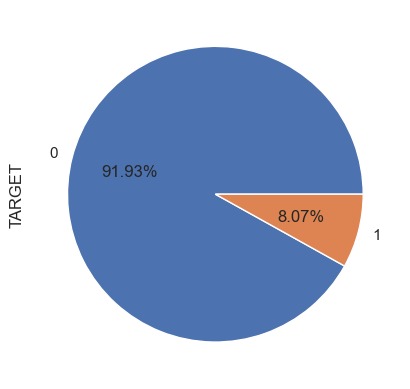

In [7]:
main_data['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

# Numerical Features

In [9]:
numerical_frame=main_data[numerical_features].copy()
numerical_frame.columns

Index(['TARGET', 'SK_ID_CURR', 'AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
       'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
       'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_CREDIT_outlier',
       'AMT_INCOME_TOTAL_outlier', 'AMT_ANNUITY_outlier',
       'AMT_GOODS_PRICE_outlier', 'YEARS_BIRTH', 'YEARS_ID_PUBLISH',
       'YEARS_REGISTRATION', 'DAYS_REGISTRATION_outlier', 'YEARS_EMPLOYED',
       'DAYS_EMPLOYED_outlier', 'YEARS_LAST_PHONE_CHANGE'],
      dtype='object')

### Functions

In [17]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [18]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [19]:
def calc_iqr(feature, data):
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [20]:
def plot_kde_vs_target(feature, main_data=main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [21]:
def plot_all_numeric_kde():
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [22]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [23]:
def median_vs_target(feature, data):
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

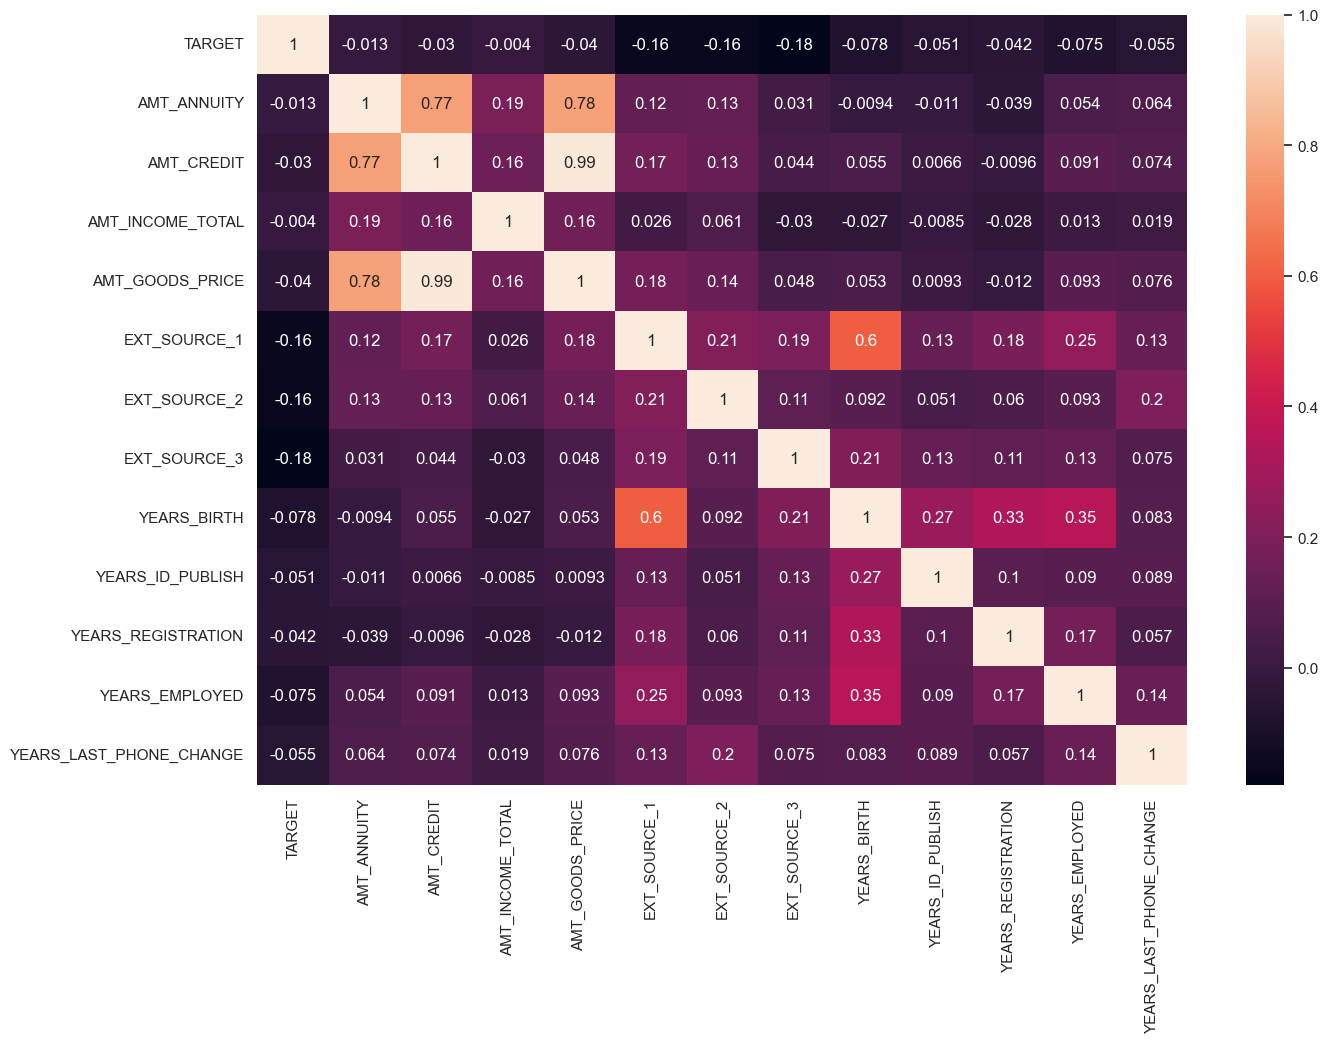

In [ ]:
temp=numerical_frame.drop(['SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
                      'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT_outlier',
                      'AMT_INCOME_TOTAL_outlier', 'AMT_ANNUITY_outlier', 'AMT_GOODS_PRICE_outlier',
                      'DAYS_REGISTRATION_outlier', 'DAYS_EMPLOYED_outlier'], axis=1)
ax=sns.heatmap(temp.corr(), annot=True)
ax.get_figure().set_size_inches(w=15, h=10)
del temp

# RATIO_ANNUITY_CREDIT

In [42]:
numerical_frame['RATIO_ANNUITY_CREDIT']=numerical_frame['AMT_ANNUITY']/numerical_frame['AMT_CREDIT']
numerical_frame['RATIO_ANNUITY_CREDIT'].isnull().sum()

12

In [43]:
numerical_frame['RATIO_ANNUITY_CREDIT'].describe()

count    307499.000000
mean          0.053695
std           0.022481
min           0.022073
25%           0.036900
50%           0.050000
75%           0.064043
max           0.124430
Name: RATIO_ANNUITY_CREDIT, dtype: float64

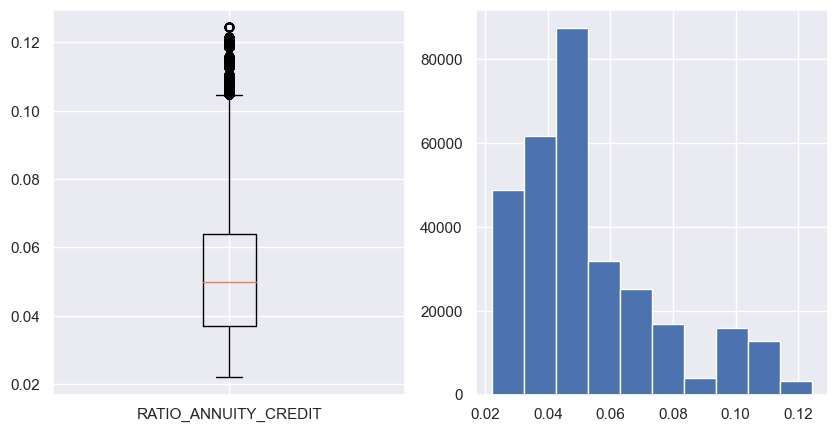

In [45]:
plot_hist_box(numerical_frame, 'RATIO_ANNUITY_CREDIT');

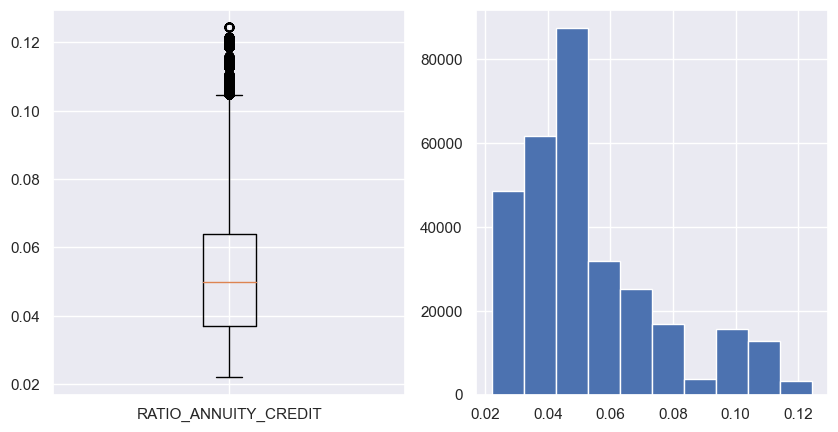

In [46]:
plot_hist_box(numerical_frame.loc[(numerical_frame['AMT_ANNUITY_outlier']==0) & (numerical_frame['AMT_CREDIT_outlier']==0), :], 'RATIO_ANNUITY_CREDIT');

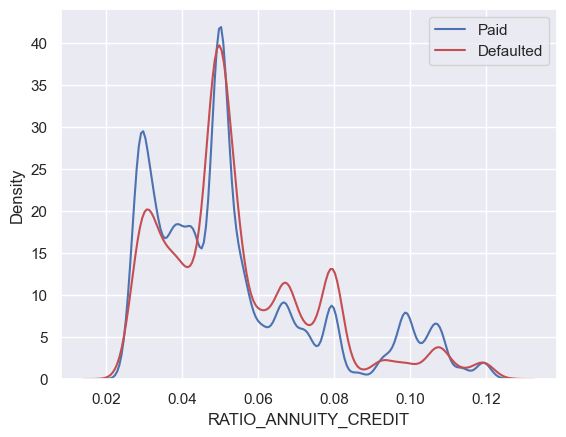

In [47]:
plot_kde_vs_target('RATIO_ANNUITY_CREDIT', numerical_frame)

(0.0211, 0.0294]     5.991161
(0.0294, 0.0356]     7.122648
(0.0356, 0.0424]     6.666275
(0.0424, 0.0483]     7.948921
(0.0483, 0.05]       8.916723
(0.05, 0.0544]       9.358425
(0.0544, 0.0671]     8.969018
(0.0671, 0.0919]    12.658784
(0.0919, 0.124]      5.139612
Name: RATIO_ANNUITY_CREDIT_binned, dtype: float64


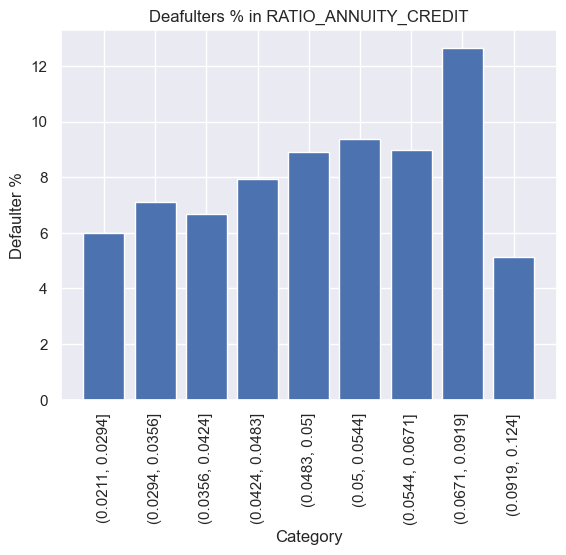

In [48]:
plot_hist_default_pct('RATIO_ANNUITY_CREDIT', numerical_frame, 9)

# RATIO_ANNUITY_INCOME

In [50]:
numerical_frame['RATIO_ANNUITY_INCOME']=numerical_frame['AMT_ANNUITY']/numerical_frame['AMT_INCOME_TOTAL']
numerical_frame['RATIO_ANNUITY_INCOME'].isnull().sum()

12

In [51]:
numerical_frame['RATIO_ANNUITY_INCOME'].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: RATIO_ANNUITY_INCOME, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

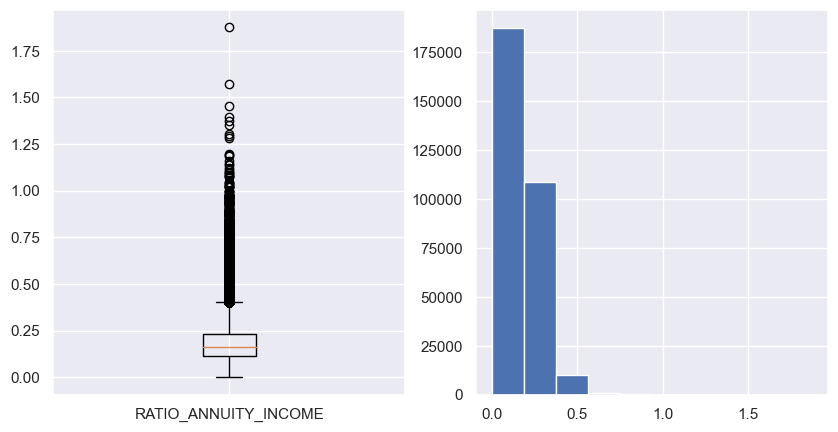

In [53]:
plot_hist_box(numerical_frame, 'RATIO_ANNUITY_INCOME')

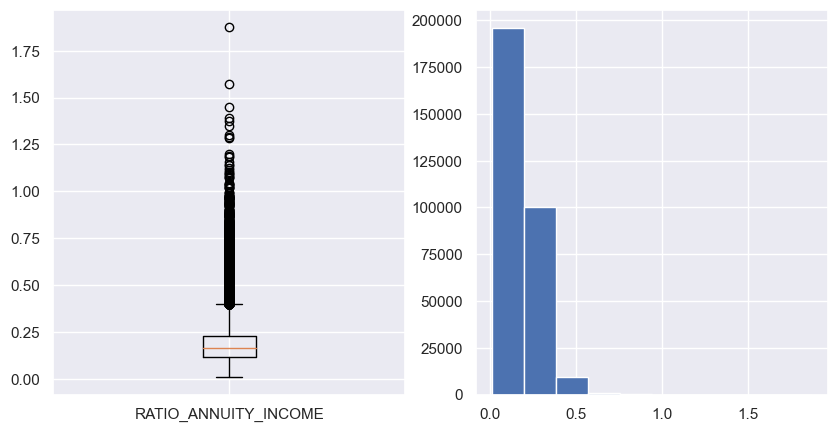

In [54]:
plot_hist_box(numerical_frame.loc[(numerical_frame['AMT_ANNUITY_outlier']==0) & (numerical_frame['AMT_INCOME_TOTAL_outlier']==0), :], 'RATIO_ANNUITY_INCOME');

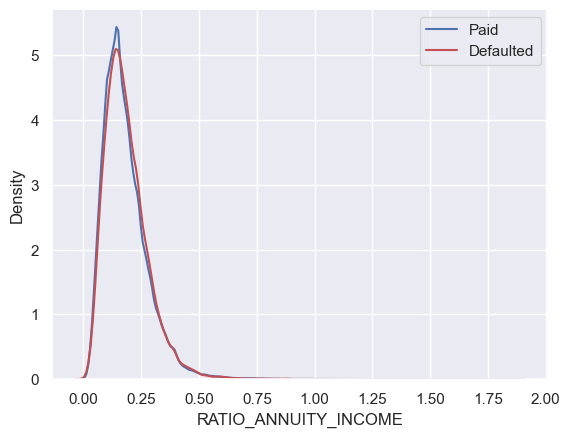

In [57]:
plot_kde_vs_target('RATIO_ANNUITY_INCOME', numerical_frame)

(-0.000776, 0.0827]    7.220417
(0.0827, 0.109]        7.243620
(0.109, 0.131]         7.826036
(0.131, 0.151]         7.674296
(0.151, 0.175]         8.483892
(0.175, 0.203]         8.456011
(0.203, 0.238]         8.748092
(0.238, 0.294]         8.674769
(0.294, 1.876]         8.332602
Name: RATIO_ANNUITY_INCOME_binned, dtype: float64


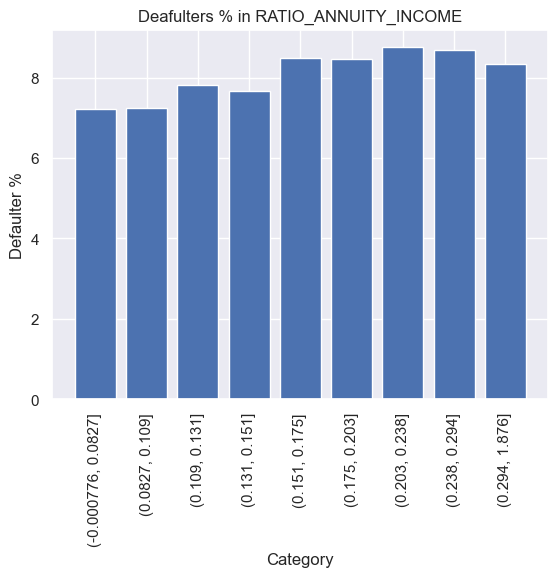

In [59]:
plot_hist_default_pct('RATIO_ANNUITY_INCOME', numerical_frame, 9)

# RATIO_INCOME_CREDIT

In [65]:
numerical_frame['RATIO_INCOME_CREDIT']=numerical_frame['AMT_INCOME_TOTAL']/numerical_frame['AMT_CREDIT']
numerical_frame['RATIO_INCOME_CREDIT'].isnull().sum()

0

In [77]:
numerical_frame['RATIO_INCOME_CREDIT'].describe()

count    307511.000000
mean          0.399670
std           0.507924
min           0.011801
25%           0.193803
50%           0.306272
75%           0.495376
max         208.003328
Name: RATIO_INCOME_CREDIT, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

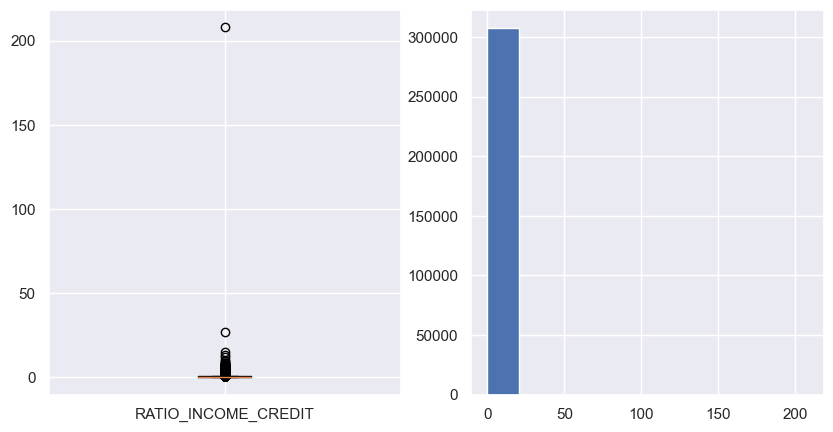

In [68]:
plot_hist_box(numerical_frame, 'RATIO_INCOME_CREDIT')

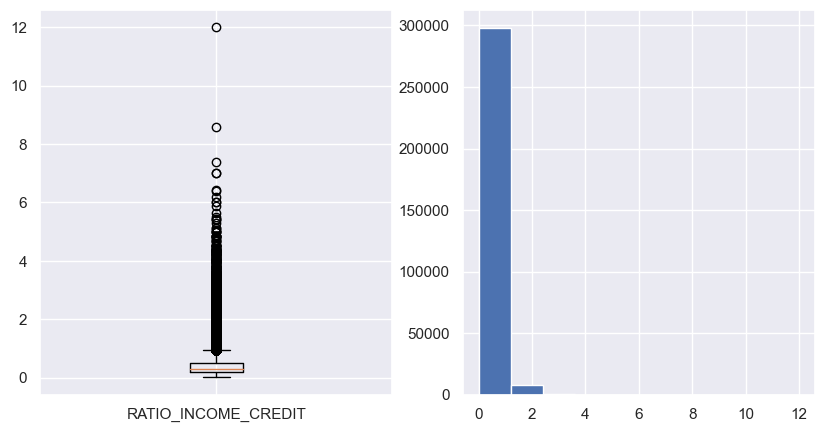

In [73]:
plot_hist_box(numerical_frame.loc[(numerical_frame['AMT_INCOME_TOTAL_outlier']==0) & (numerical_frame['AMT_CREDIT_outlier']==0), :], 'RATIO_INCOME_CREDIT');
good_frame=numerical_frame.loc[(numerical_frame['AMT_INCOME_TOTAL_outlier']==0) & (numerical_frame['AMT_CREDIT_outlier']==0), :]

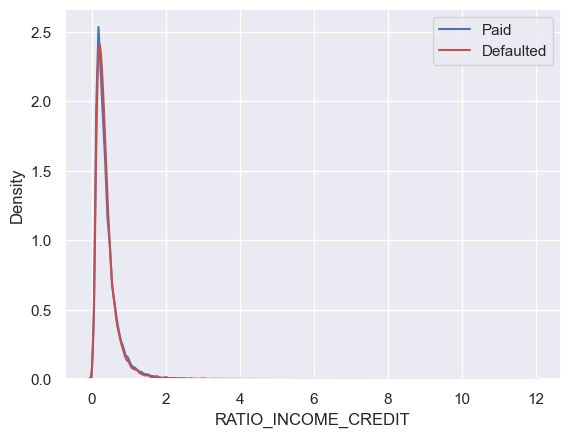

In [74]:
plot_kde_vs_target('RATIO_INCOME_CREDIT', good_frame)

(0.0108, 0.139]    7.085351
(0.139, 0.181]     7.571956
(0.181, 0.227]     8.180855
(0.227, 0.278]     8.755679
(0.278, 0.334]     8.866491
(0.334, 0.41]      8.810390
(0.41, 0.512]      8.600194
(0.512, 0.719]     7.882612
(0.719, 12.0]      7.017647
Name: RATIO_INCOME_CREDIT_binned, dtype: float64


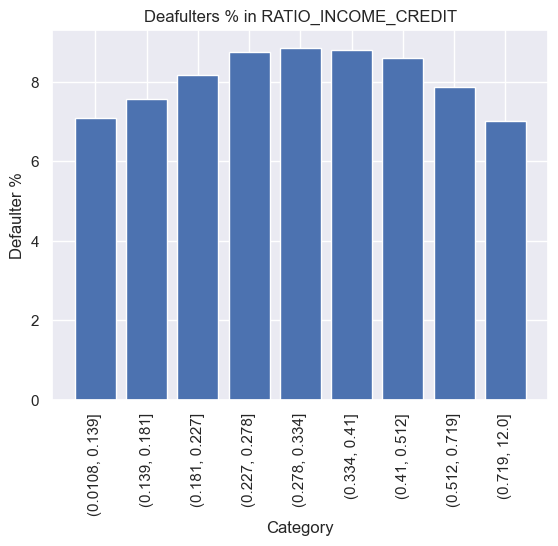

In [76]:
plot_hist_default_pct('RATIO_INCOME_CREDIT', good_frame, 9)

# RATIO_EMPLOYED_BIRTH

In [78]:
numerical_frame['RATIO_EMPLOYED_BIRTH']=numerical_frame['YEARS_EMPLOYED']/numerical_frame['YEARS_BIRTH']
numerical_frame['RATIO_EMPLOYED_BIRTH'].isnull().sum()

55374

In [79]:
numerical_frame['RATIO_EMPLOYED_BIRTH'].describe()

count    252137.000000
mean          0.156861
std           0.133549
min          -0.000000
25%           0.056099
50%           0.118733
75%           0.219170
max           0.728811
Name: RATIO_EMPLOYED_BIRTH, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

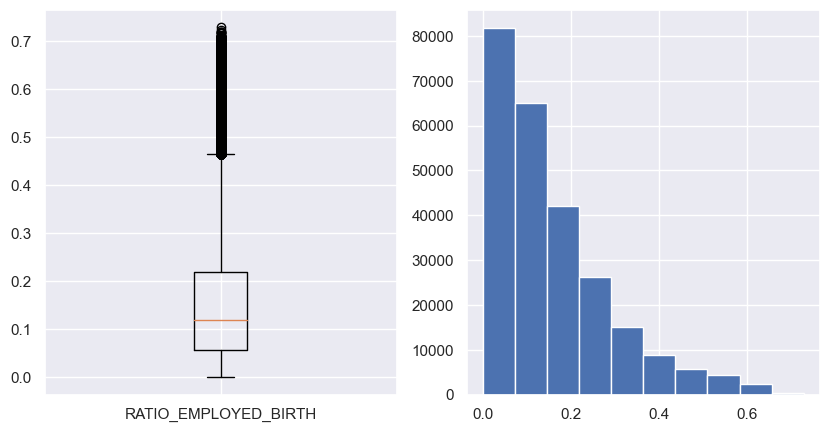

In [80]:
plot_hist_box(numerical_frame, 'RATIO_EMPLOYED_BIRTH')

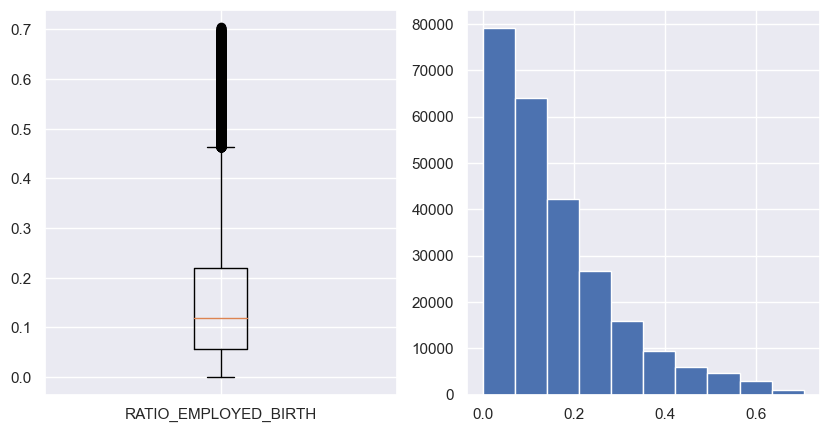

In [81]:
plot_hist_box(numerical_frame.loc[(numerical_frame['DAYS_EMPLOYED_outlier']==0), :], 'RATIO_EMPLOYED_BIRTH');
good_frame=numerical_frame.loc[(numerical_frame['DAYS_EMPLOYED_outlier']==0), :]

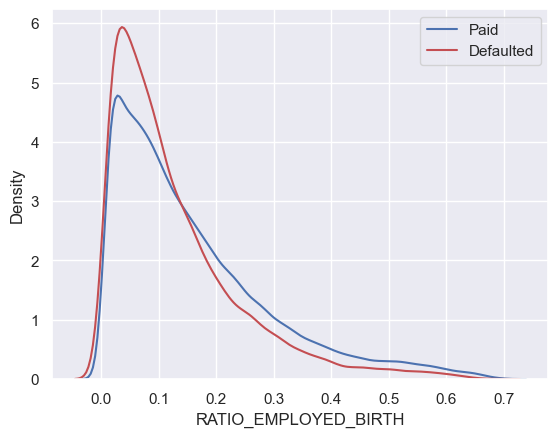

In [82]:
plot_kde_vs_target('RATIO_EMPLOYED_BIRTH', good_frame)

(-0.001, 0.0264]    10.600164
(0.0264, 0.05]      10.900068
(0.05, 0.075]       10.610875
(0.075, 0.103]       9.879320
(0.103, 0.137]       8.982827
(0.137, 0.178]       8.322325
(0.178, 0.235]       7.069409
(0.235, 0.33]        6.576458
(0.33, 0.705]        5.012674
Name: RATIO_EMPLOYED_BIRTH_binned, dtype: float64


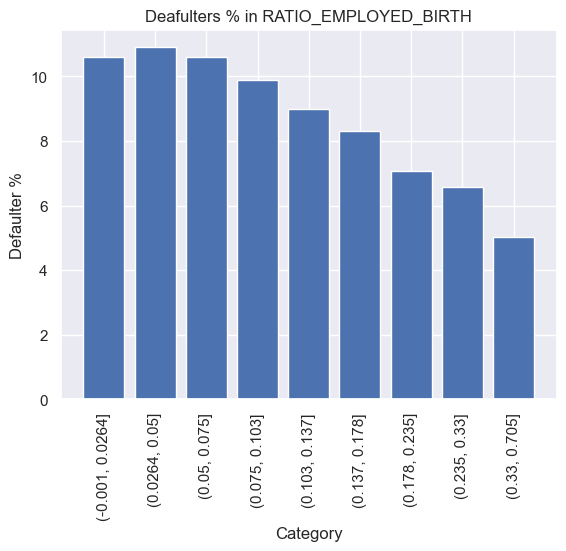

In [83]:
plot_hist_default_pct('RATIO_EMPLOYED_BIRTH', good_frame, 9)